## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import umap

from config import (
    OPTIMAL_K_SUMMARY_PATH,
    OUTPUT_DIR,
    RAW_PATH,
    SCALED_PATH,
    VALIDATION_RESULTS_PATH,
    VISUALIZATION_SUMMARY_PATH,
    DISCLOSURE_THRESHOLD,
    PLOTS_DIR,
    heatmap_path,
)

from clustering_helpers import load_data, plot_clusters_umap,apply_disclosure_control

# -----------------------------
# Setup
# -----------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load Data & Compute UMAP

In [2]:
print(" Loading datasets...")
X_raw, X_scaled, patient_ids = load_data(RAW_PATH, SCALED_PATH)

# Compute UMAP embedding from raw data
#umap_values = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(X_raw)
#print (umap_values)

 Loading datasets...


## 3. Load Optimal k and Validation Data

In [3]:
opt_k_df = pd.read_csv(OPTIMAL_K_SUMMARY_PATH)
val_df = pd.read_csv(VALIDATION_RESULTS_PATH)
print(f" Loaded {len(opt_k_df)} optimal-k rows and {len(val_df)} validation rows")

 Loaded 5 optimal-k rows and 6 validation rows


## 4. Generate Visualizations

In [4]:
summary_out = []
print("\n Generating visualizations...\n")

label_files = [f for f in os.listdir(OUTPUT_DIR)
               if f.startswith("labels_") and f.endswith(".csv.gz")]

for file in sorted(label_files):
    cfg = file.replace("labels_", "").replace(".csv.gz", "")
    labels_file = os.path.join(OUTPUT_DIR, file)
    labels_df = pd.read_csv(labels_file, compression="gzip")
    labels = labels_df["cluster"].values
    n_clusters = len([x for x in np.unique(labels) if x != -1])
    print(f"{cfg}: loaded labels ({n_clusters} clusters)")

    #plot_clusters_umap(umap_values, labels, cfg)

    # summary report
    val_row = val_df[val_df["config"] == cfg]
    sil = val_row["silhouette"].values[0] 
    ch = val_row["calinski_harabasz"].values[0] 

    k_opt_series = opt_k_df.loc[opt_k_df["config"] == cfg, "k_opt"]
    k_opt = int(k_opt_series.values[0]) if not k_opt_series.empty and not pd.isna(k_opt_series.values[0]) else np.nan
    print (k_opt_series)
    
    summary_out.append({
        "config": cfg,
        "k": k_opt,
        "clusters_found": n_clusters,
        "silhouette": sil,
        "calinski_harabasz": ch
    })


 Generating visualizations...

pca_agglomerative_euclidean: loaded labels (1 clusters)
3    3.0
Name: k_opt, dtype: float64
pca_kmeans_euclidean: loaded labels (4 clusters)
2    4.0
Name: k_opt, dtype: float64
pca_optics: loaded labels (58 clusters)
4   NaN
Name: k_opt, dtype: float64
raw_agglomerative_gower: loaded labels (1 clusters)
1    6.0
Name: k_opt, dtype: float64
raw_kmedoids_gower: loaded labels (2 clusters)
0    2.0
Name: k_opt, dtype: float64
raw_optics: loaded labels (57 clusters)
Series([], Name: k_opt, dtype: float64)


## 5. Save Summary

In [5]:
summary_df = pd.DataFrame(summary_out)
summary_df.to_csv(VISUALIZATION_SUMMARY_PATH, index=False)

print("\n All visualizations complete.")
print(" Summary saved to:", VISUALIZATION_SUMMARY_PATH)
print(" plots saved to", OUTPUT_DIR)
print(summary_df)


 All visualizations complete.
 Summary saved to: /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/visualization_summary.csv
 plots saved to /Users/cj9491/Documents/UOB/REDUCE/git/reducehf/output/clustering/
                        config    k  clusters_found  silhouette  \
0  pca_agglomerative_euclidean  3.0               1         NaN   
1         pca_kmeans_euclidean  4.0               4    0.272457   
2                   pca_optics  NaN              58    0.973118   
3      raw_agglomerative_gower  6.0               1         NaN   
4           raw_kmedoids_gower  2.0               2    0.336239   
5                   raw_optics  NaN              57    0.961110   

   calinski_harabasz  
0                NaN  
1         909.819620  
2       20106.283300  
3                NaN  
4         304.378301  
5        9715.279294  


## 6. Heatmap

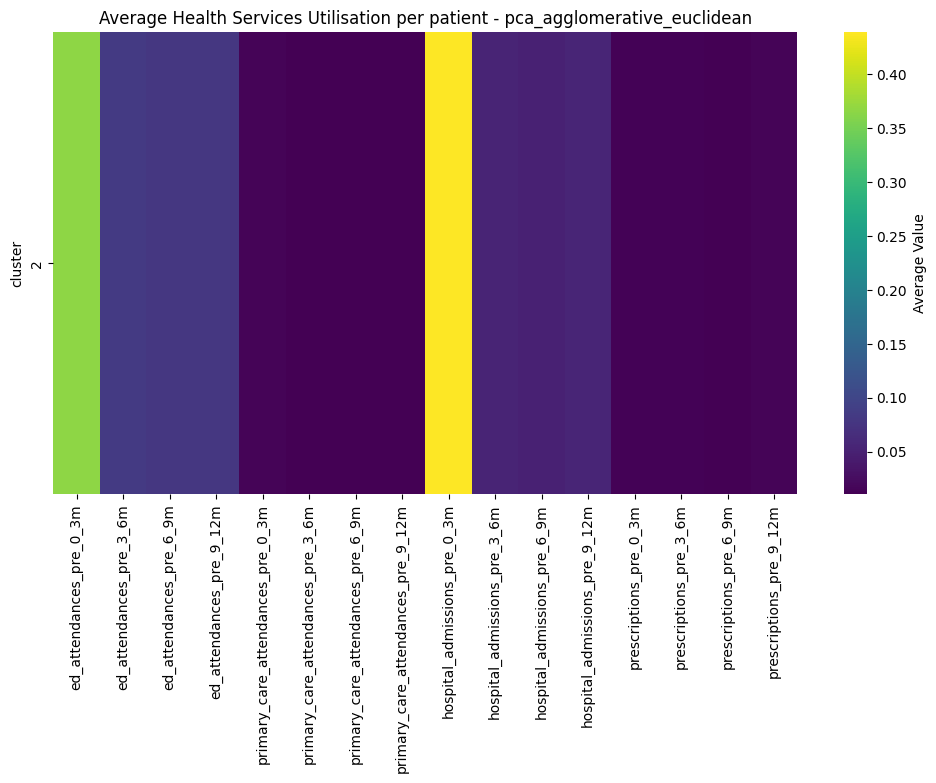

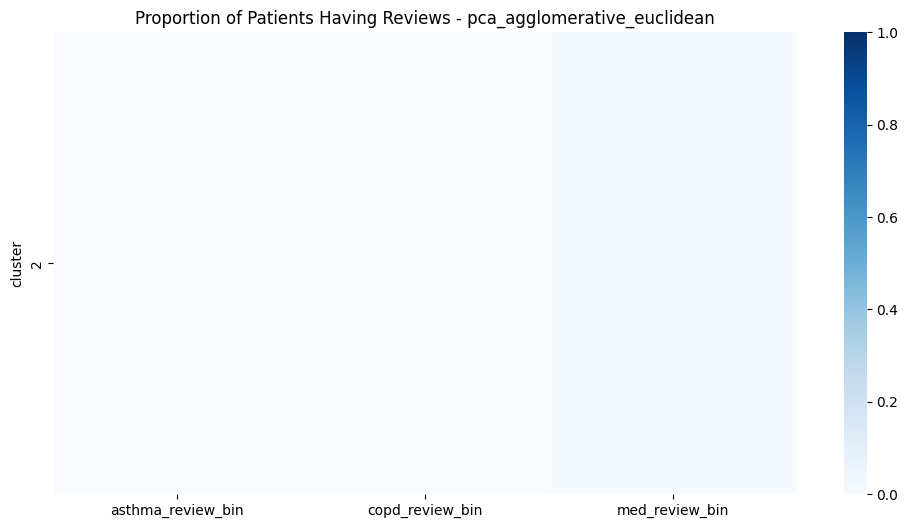

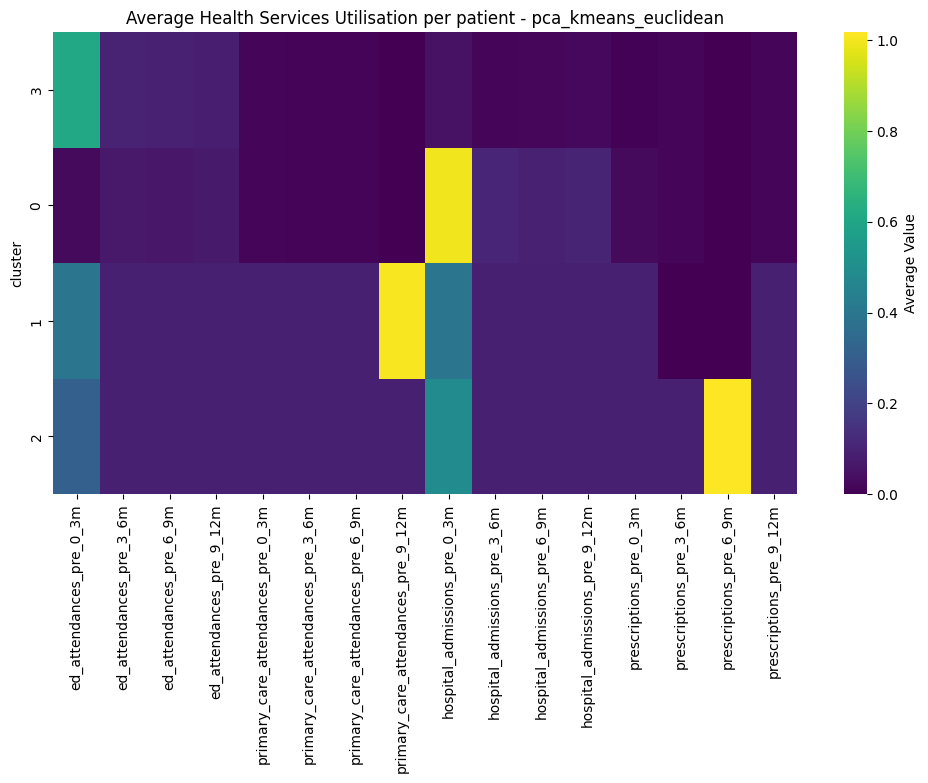

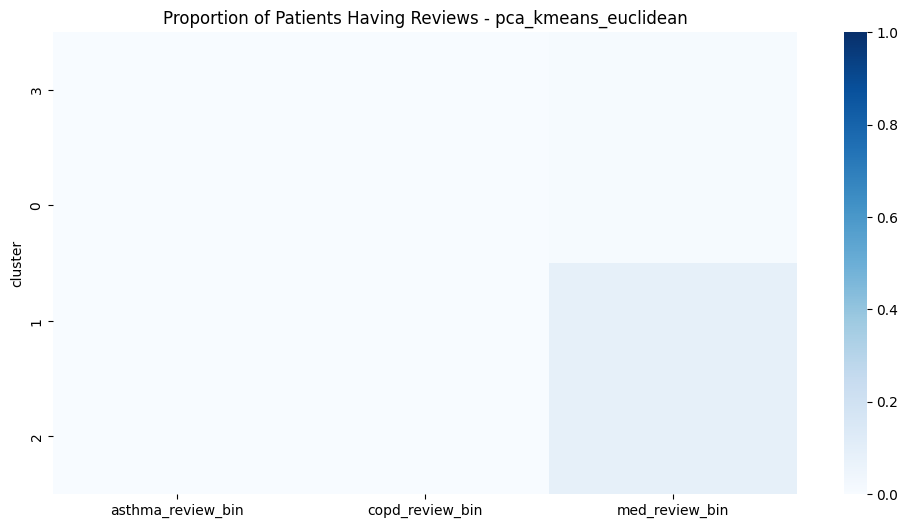

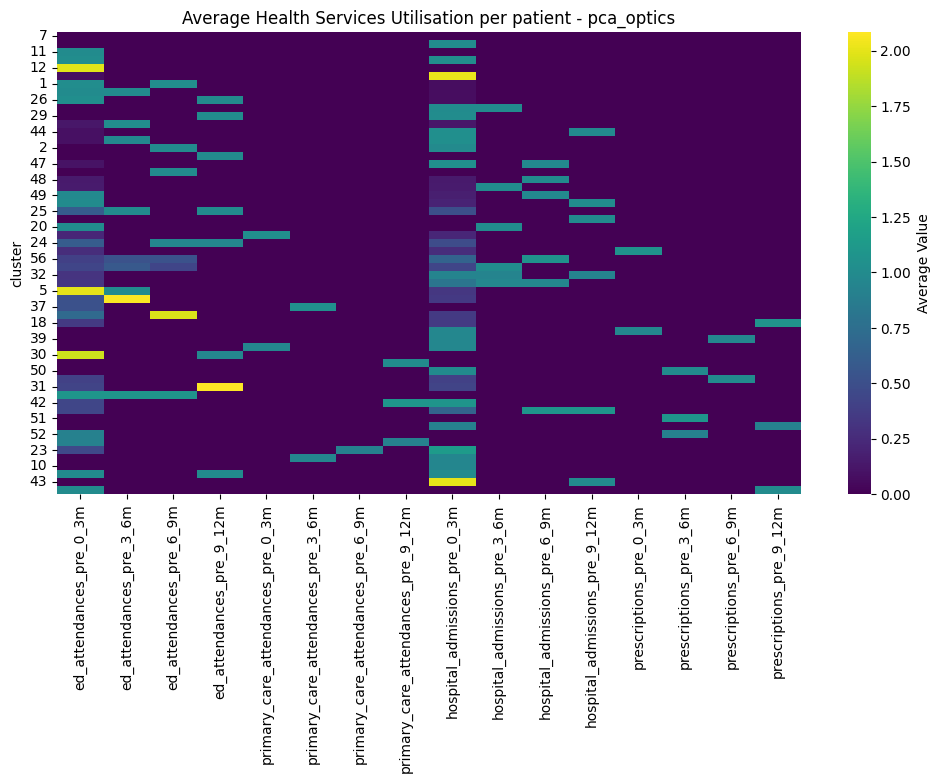

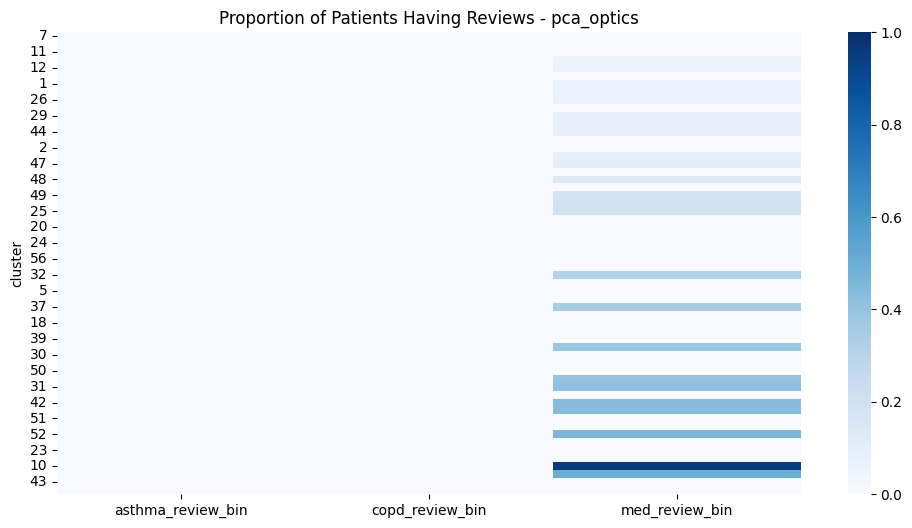

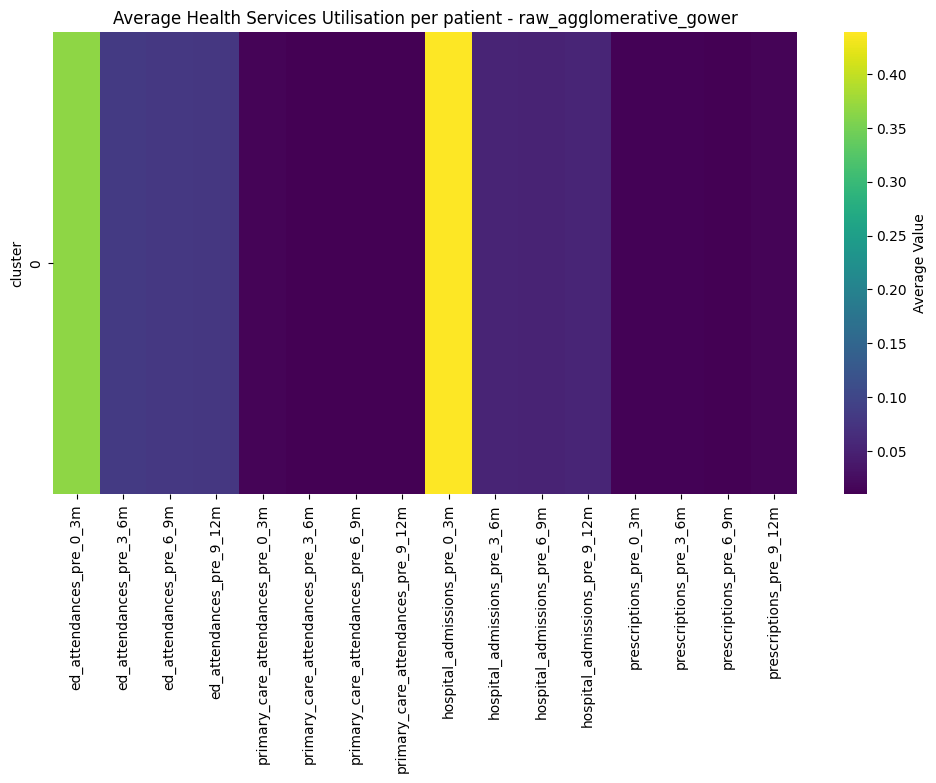

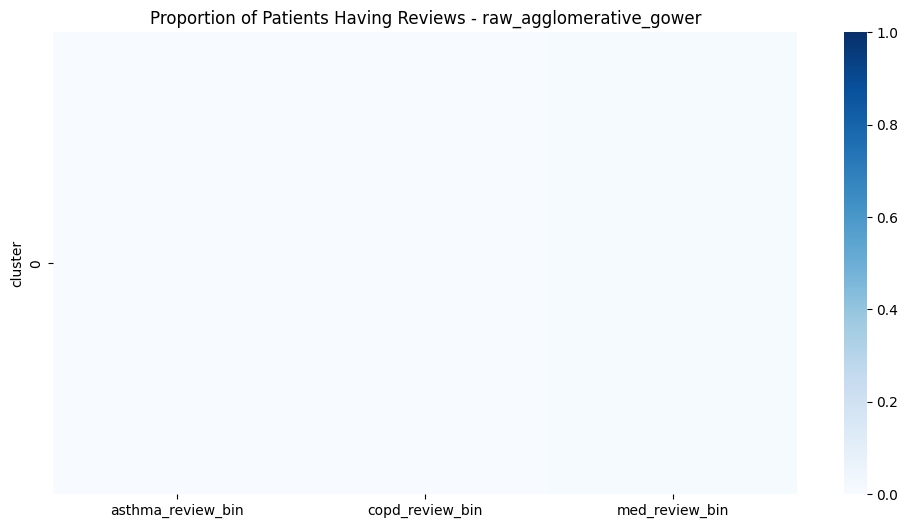

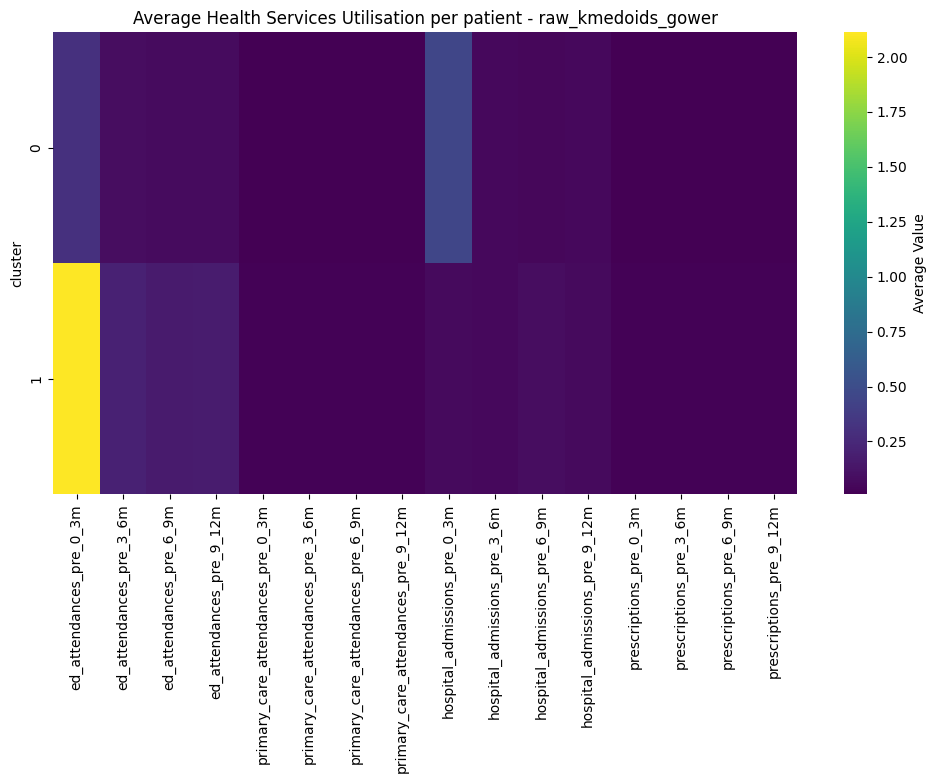

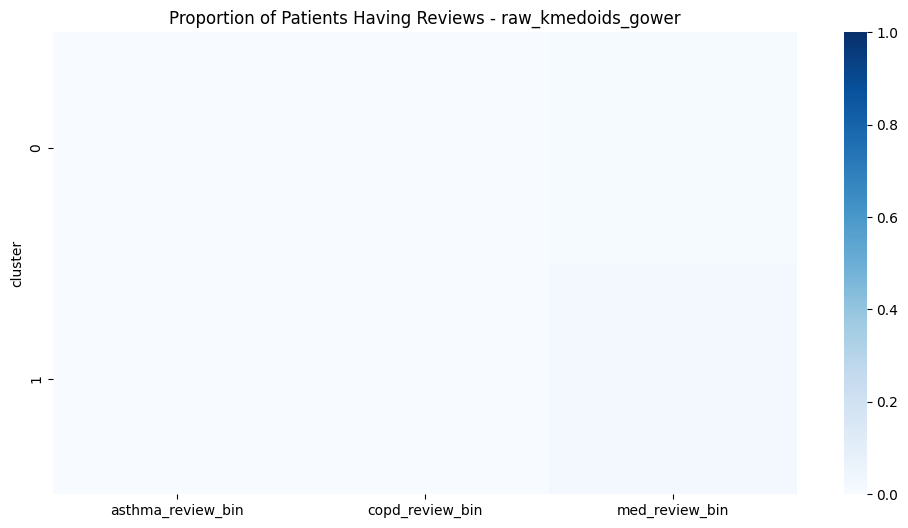

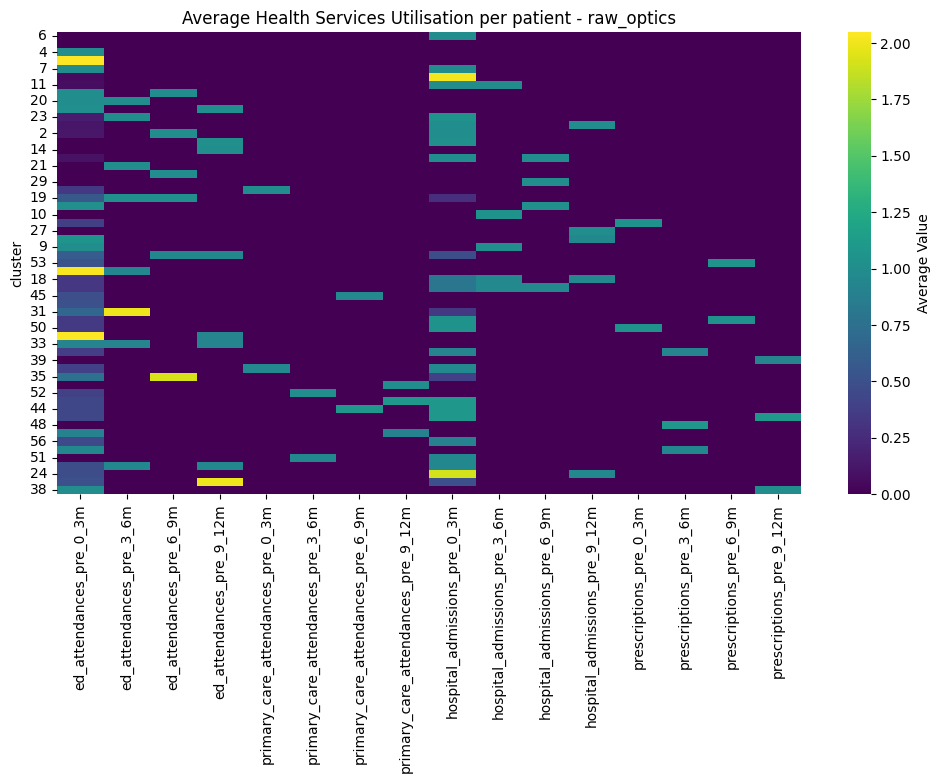

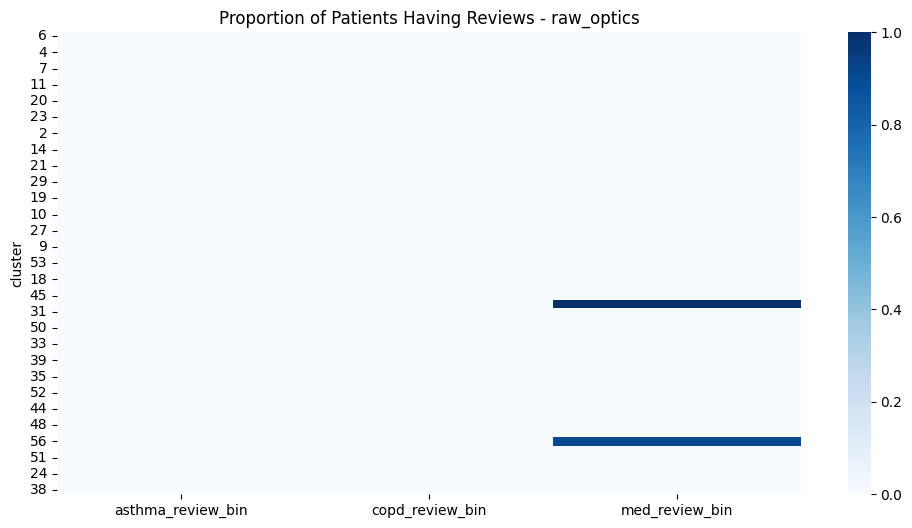

In [8]:
raw_df = pd.read_csv(RAW_PATH).drop(columns=["patient_id"])

for file in sorted(label_files):
    df = raw_df.copy()
    cfg = file.replace("labels_", "").replace(".csv.gz", "")
    labels = pd.read_csv(os.path.join(OUTPUT_DIR, file), compression="gzip")["cluster"].values
    df["cluster"] = labels
    df = df.loc[~(df.cluster==-1)]

    numeric_cols = df.columns[~df.columns.str.contains("cluster|_bin")] #utilisation
    binary_cols  = df.columns[df.columns.str.contains("_bin")] # reviews

    cluster_order = df["cluster"].value_counts().index

    cluster_sizes = df.groupby("cluster").size().loc[cluster_order]
    numeric_counts = df.groupby("cluster")[numeric_cols].sum().loc[cluster_order]
    binary_counts  = df.groupby("cluster")[binary_cols].sum().loc[cluster_order]

    numeric_counts_rounded = numeric_counts.apply(
        apply_disclosure_control,
        threshold=DISCLOSURE_THRESHOLD
    )
    
    binary_counts_rounded = binary_counts.apply(
        apply_disclosure_control,
        threshold=DISCLOSURE_THRESHOLD
    )

    numeric_means_derived = numeric_counts_rounded.div(cluster_sizes, axis=0).loc[cluster_order]
    binary_props_derived  = binary_counts_rounded.div(cluster_sizes, axis=0).loc[cluster_order]

    
    numeric_means_derived.to_csv(os.path.join(OUTPUT_DIR, f"{cfg}_utilisation_means.csv"))
    numeric_counts_rounded.to_csv(os.path.join(OUTPUT_DIR, f"{cfg}_utilisation_counts.csv"))

    plt.figure(figsize=(12, 6))
    sns.heatmap(numeric_means_derived, cmap="viridis", cbar_kws={"label": "Average Value"})
    plt.title(f"Average Health Services Utilisation per patient - {cfg}")
    plt.savefig(heatmap_path(f"{cfg}_numeric"))
    plt.show()

    

    binary_props_derived.to_csv(os.path.join(OUTPUT_DIR, f"{cfg}_binary_means.csv"))
    binary_counts_rounded.to_csv(os.path.join(OUTPUT_DIR, f"{cfg}_binary_counts.csv"))

    plt.figure(figsize=(12, 6))
    sns.heatmap(binary_props_derived, cmap="Blues",  fmt=".2f", vmin=0, vmax=1)
    plt.title(f"Proportion of Patients Having Reviews - {cfg}")
    plt.savefig(heatmap_path(f"{cfg}_binary"))
    plt.show()